### 1. Data Loading and Initial Exploration

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


try:
    df = pd.read_csv('Country-data (1).csv')
    print("Data loaded successfully.")
    print("\nFirst 5 rows of the dataset:")
    display(df.head())
except FileNotFoundError:
    print("Error: 'Country-data (1).csv' not found. Please ensure the file is uploaded.")
    df = None


Data loaded successfully.

First 5 rows of the dataset:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [6]:
if df is not None:
    print("\nDataset Info:")
    df.info()
    print("\nMissing values:")
    display(df.isnull().sum())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB

Missing values:


,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


### 2. Data Preprocessing and Feature Engineering

In [7]:
from sklearn.preprocessing import StandardScaler

if df is not None:

    country_names = df['country']
    X_clustering = df.drop('country', axis=1)


    scaler = StandardScaler()
    X_clustering_scaled = scaler.fit_transform(X_clustering)


    X_clustering_scaled_df = pd.DataFrame(X_clustering_scaled, columns=X_clustering.columns)

    print("\nData preprocessing for clustering complete. Numerical features scaled.")
    print("First 5 rows of the scaled data:")
    display(X_clustering_scaled_df.head())


Data preprocessing for clustering complete. Numerical features scaled.
First 5 rows of the scaled data:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


### 4. Clustering Models (K-Means, DBSCAN)

#### K-Means Clustering


--- Applying K-Means Clustering ---


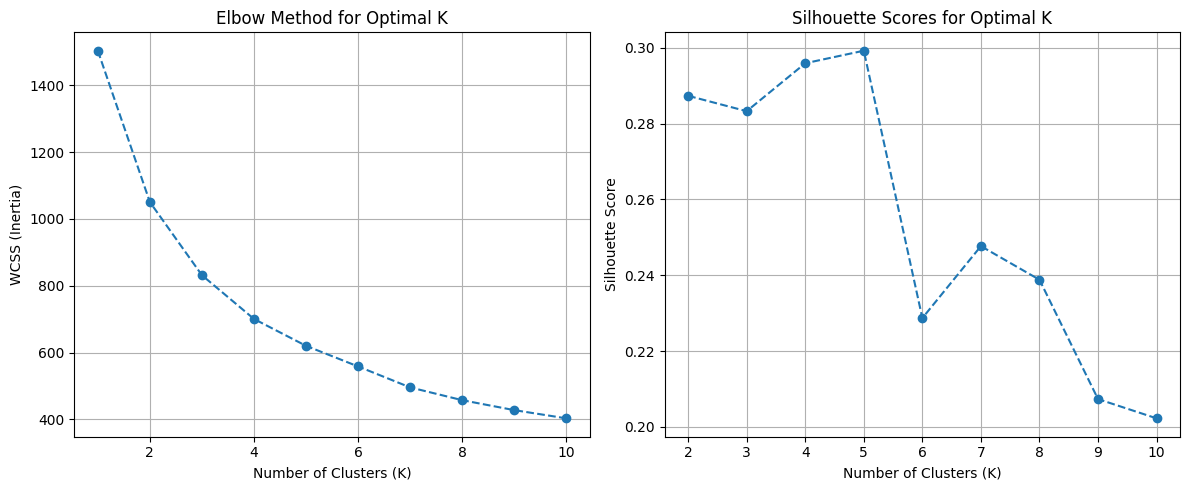


Review the Elbow Method and Silhouette Score plots to choose an optimal K value.


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


if 'X_clustering_scaled' in locals():
    print("\n--- Applying K-Means Clustering ---")


    wcss = [] # Within-cluster sum of squares
    silhouette_scores = []
    max_clusters = 10 # Let's test up to 10 clusters

    for i in range(1, max_clusters + 1):
        kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
        kmeans.fit(X_clustering_scaled)
        wcss.append(kmeans.inertia_)
        if i > 1:
            silhouette_scores.append(silhouette_score(X_clustering_scaled, kmeans.labels_))

    # Plot Elbow Method
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, max_clusters + 1), wcss, marker='o', linestyle='--')
    plt.title('Elbow Method for Optimal K')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('WCSS (Inertia)')
    plt.grid(True)

    # Plot Silhouette Scores
    plt.subplot(1, 2, 2)
    plt.plot(range(2, max_clusters + 1), silhouette_scores, marker='o', linestyle='--')
    plt.title('Silhouette Scores for Optimal K')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("\nReview the Elbow Method and Silhouette Score plots to choose an optimal K value.")

else:
    print("X_clustering_scaled not found. Please ensure data preprocessing has been run successfully.")


In [9]:
from sklearn.cluster import KMeans


optimal_k = 4 # You can change this value based on the plots from the previous cell

if 'X_clustering_scaled' in locals() and 'df' in locals():
    kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
    df['KMeans_Cluster'] = kmeans_final.fit_predict(X_clustering_scaled)
    print(f"K-Means clustering with K={optimal_k} completed. First 5 rows with cluster assignments:")
    display(df[['country', 'KMeans_Cluster']].head())
    print("K-Means Cluster distribution:")
    display(df['KMeans_Cluster'].value_counts().sort_index())
else:
    print("Required data (df or X_clustering_scaled) not found. Please ensure previous steps ran successfully.")

K-Means clustering with K=4 completed. First 5 rows with cluster assignments:


,country,KMeans_Cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


K-Means Cluster distribution:


,count
KMeans_Cluster,
0,32
1,47
2,85
3,3


#### DBSCAN Clustering

In [10]:
from sklearn.cluster import DBSCAN

if 'X_clustering_scaled' in locals() and 'df' in locals():
    print("\n--- Applying DBSCAN Clustering ---")
    # DBSCAN requires careful parameter tuning (eps, min_samples)
    # These are initial values, and might need to be adjusted based on data density
    dbscan = DBSCAN(eps=0.5, min_samples=5) # Example parameters
    df['DBSCAN_Cluster'] = dbscan.fit_predict(X_clustering_scaled)

    print("DBSCAN clustering completed. First 5 rows with cluster assignments:")
    display(df[['country', 'DBSCAN_Cluster']].head())
    print("DBSCAN Cluster distribution (Note: -1 indicates noise points):")
    display(df['DBSCAN_Cluster'].value_counts().sort_index())

    print("\nClustering algorithms applied. Now we can analyze the clusters for insights.")
else:
    print("Required data (df or X_clustering_scaled) not found. Please ensure previous steps ran successfully.")


--- Applying DBSCAN Clustering ---
DBSCAN clustering completed. First 5 rows with cluster assignments:


,country,DBSCAN_Cluster
0,Afghanistan,-1
1,Albania,-1
2,Algeria,-1
3,Angola,-1
4,Antigua and Barbuda,-1


DBSCAN Cluster distribution (Note: -1 indicates noise points):


,count
DBSCAN_Cluster,
-1,167



Clustering algorithms applied. Now we can analyze the clusters for insights.


### 6. Visualization

#### K-Means Cluster Visualization

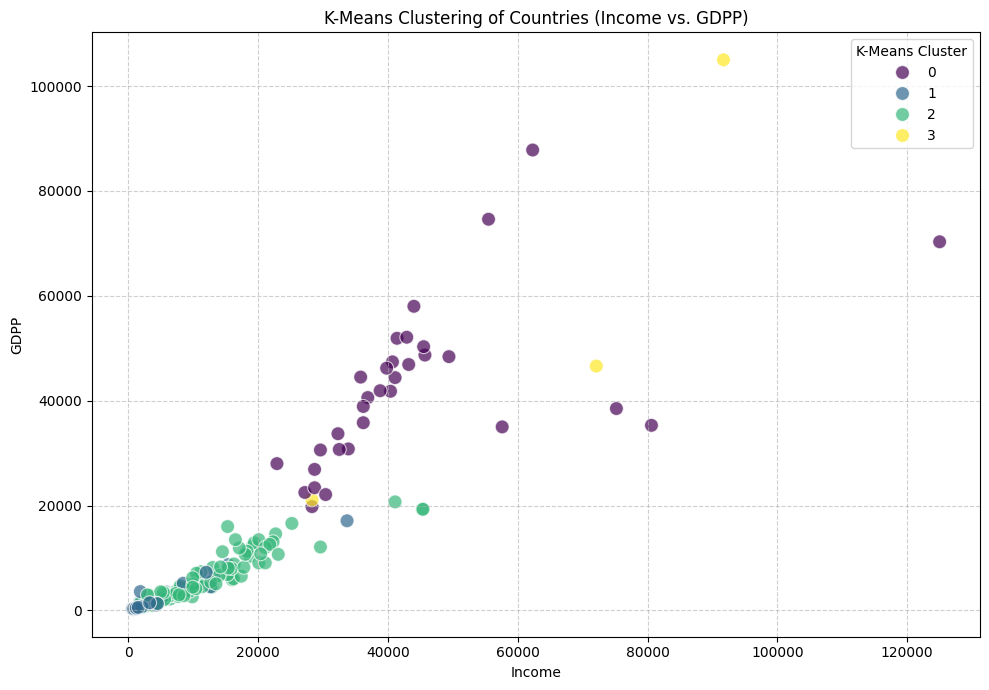

In [11]:
if 'df' in locals() and 'KMeans_Cluster' in df.columns:
    plt.figure(figsize=(10, 7))
    sns.scatterplot(x='income', y='gdpp', hue='KMeans_Cluster', data=df, palette='viridis', s=100, alpha=0.7)
    plt.title('K-Means Clustering of Countries (Income vs. GDPP)')
    plt.xlabel('Income')
    plt.ylabel('GDPP')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='K-Means Cluster')
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame 'df' or 'KMeans_Cluster' column not found. Please ensure K-Means clustering has been run successfully.")